Dataset Shape: (100000, 21)

Best model loaded successfully!

========== MODEL EVALUATION ==========
Mean Absolute Error (MAE): 1295.01
Root Mean Squared Error (RMSE): 1624.32
R2 Score: 0.9376

========== ACTUAL VS PREDICTED ==========
   Actual Cost  Predicted Cost
0     23965.48      24704.0361
1     27486.52      24168.9823
2     22889.10      20147.0240
3     17938.27      20683.3847
4     37995.30      36939.1218
5     37407.20      36452.5290
6     29910.46      30623.3847
7     22537.42      24595.7260
8     26038.68      25540.6924
9     24133.30      26914.8661


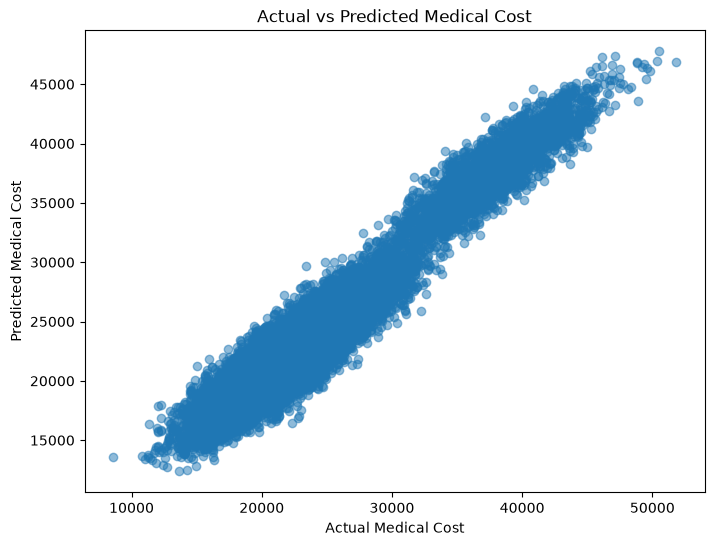

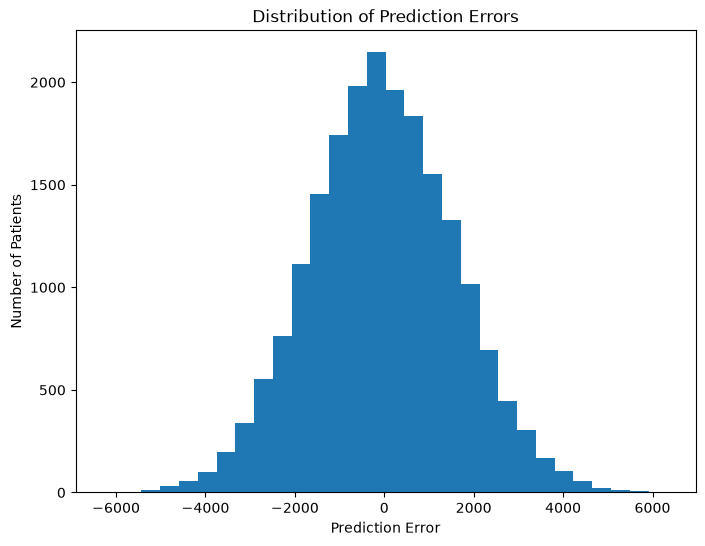


========== SAMPLE PREDICTIONS ==========
Actual: ₹ 23965.48  | Predicted: ₹ 24704.04
Actual: ₹ 27486.52  | Predicted: ₹ 24168.98
Actual: ₹ 22889.1  | Predicted: ₹ 20147.02
Actual: ₹ 17938.27  | Predicted: ₹ 20683.38
Actual: ₹ 37995.3  | Predicted: ₹ 36939.12
Actual: ₹ 37407.2  | Predicted: ₹ 36452.53
Actual: ₹ 29910.46  | Predicted: ₹ 30623.38
Actual: ₹ 22537.42  | Predicted: ₹ 24595.73
Actual: ₹ 26038.68  | Predicted: ₹ 25540.69
Actual: ₹ 24133.3  | Predicted: ₹ 26914.87

MODEL EVALUATION COMPLETED
Model Performance: Very Good


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv("../outputs/healthcare_cost_dataset.csv")

print("Dataset Shape:", df.shape)


features = [
    "Age",
    "Gender",
    "Region",
    "Socioeconomic_Status",
    "Primary_Diagnosis",
    "Blood_Glucose_mg_dL",
    "HbA1c_%",
    "Total_Cholesterol_mg_dL",
    "Treatment_Type",
    "Treatment_Outcome",
    "Imaging_Type",
    "Hospital_Type",
    "Insurance_Covered",
    "BMI"
]

target = "Treatment_Cost_INR"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = joblib.load(
    "../outputs/best_medical_cost_model.pkl"
)

print("\nBest model loaded successfully!")


y_pred = model.predict(X_test)


mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)


print("\n========== MODEL EVALUATION ==========")

print("Mean Absolute Error (MAE):",
      round(mae, 2))

print("Root Mean Squared Error (RMSE):",
      round(rmse, 2))

print("R2 Score:",
      round(r2, 4))


comparison = pd.DataFrame({
    "Actual Cost": y_test.values,
    "Predicted Cost": y_pred
})

print("\n========== ACTUAL VS PREDICTED ==========")

print(comparison.head(10))


plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Medical Cost")
plt.ylabel("Predicted Medical Cost")

plt.title(
    "Actual vs Predicted Medical Cost"
)

plt.show()


errors = y_test.values - y_pred

plt.figure(figsize=(8, 6))

plt.hist(
    errors,
    bins=30
)

plt.xlabel("Prediction Error")
plt.ylabel("Number of Patients")

plt.title(
    "Distribution of Prediction Errors"
)

plt.show()

print("\n========== SAMPLE PREDICTIONS ==========")

for i in range(10):

    print(
        "Actual: ₹",
        round(y_test.iloc[i], 2),
        " | Predicted: ₹",
        round(y_pred[i], 2)
    )


print("\n========================================")
print("MODEL EVALUATION COMPLETED")
print("========================================")

if r2 >= 0.80:
    print("Model Performance: Very Good")

elif r2 >= 0.60:
    print("Model Performance: Good")

elif r2 >= 0.40:
    print("Model Performance: Moderate")

else:
    print("Model Performance: Needs Improvement")